In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import json
import os

tf.random.set_seed(42)
np.random.seed(42)

df = pd.read_csv('../data/tarkwa_nasa_monthly.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(df[['date', 'rainfall_mm']].head())

Dataset shape: (438, 11)
Date range: 1990-01-01 00:00:00 to 2026-06-01 00:00:00
        date  rainfall_mm
0 1990-01-01        36.92
1 1990-02-01        98.45
2 1990-03-01        70.49
3 1990-04-01       251.53
4 1990-05-01       187.32


In [2]:
split_date = '2019-01-01'

train_df = df[df['date'] < split_date].reset_index(drop=True)
test_df  = df[df['date'] >= split_date].reset_index(drop=True)

train_dates = train_df['date']
test_dates  = test_df['date']

# Scale rainfall to [0,1] for LSTM stability — fit scaler on TRAIN only
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_df[['rainfall_mm']].values)
test_scaled  = scaler.transform(test_df[['rainfall_mm']].values)

print(f"Training months: {len(train_df)} (Jan 1990 – Dec 2018)")
print(f"Test months:     {len(test_df)}  (Jan 2019 – Jun 2026)")

Training months: 348 (Jan 1990 – Dec 2018)
Test months:     90  (Jan 2019 – Jun 2026)


In [3]:
LOOKBACK = 12  # use trailing 12 months to predict the next month

def create_sequences(data, lookback):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

# Combine train+test scaled series so test sequences can see trailing history from train
full_scaled = np.concatenate([train_scaled, test_scaled], axis=0)

X_all, y_all = create_sequences(full_scaled, LOOKBACK)
n_train = len(train_scaled) - LOOKBACK  # number of training sequences

X_train_seq, y_train_seq = X_all[:n_train], y_all[:n_train]
X_test_seq,  y_test_seq  = X_all[n_train:], y_all[n_train:]

X_train_seq = X_train_seq.reshape((X_train_seq.shape[0], LOOKBACK, 1))
X_test_seq  = X_test_seq.reshape((X_test_seq.shape[0], LOOKBACK, 1))

print(f"Train sequences: {X_train_seq.shape}")
print(f"Test sequences:  {X_test_seq.shape}")

Train sequences: (336, 12, 1)
Test sequences:  (90, 12, 1)


In [4]:
model = Sequential([
    LSTM(64, activation='tanh', return_sequences=True, input_shape=(LOOKBACK, 1)),
    Dropout(0.2),
    LSTM(32, activation='tanh'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

early_stop = EarlyStopping(monitor='loss', patience=15, restore_best_weights=True)

history = model.fit(
    X_train_seq, y_train_seq,
    epochs=150,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0734
Epoch 2/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0531
Epoch 3/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0525
Epoch 4/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0501
Epoch 5/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0513
Epoch 6/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0476
Epoch 7/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0468
Epoch 8/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0434
Epoch 9/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0373
Epoch 10/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0370
Epoch 11/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0341
Epoch 12/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0325
Epoch 13/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0311
Epoch 14/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0319
Epoch 15/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0305
Epoc

In [5]:
pred_scaled = model.predict(X_test_seq)
predictions = scaler.inverse_transform(pred_scaled).flatten()
predictions = np.maximum(predictions, 0)  # rainfall cannot be negative

y_test = scaler.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

# Align dates — first LOOKBACK test-adjacent points are consumed as context
test_dates_aligned = test_dates.reset_index(drop=True)

print(f"Predictions shape: {predictions.shape}")
print(f"Actual shape:      {y_test.shape}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
Predictions shape: (90,)
Actual shape:      (90,)


In [6]:
mae  = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2   = r2_score(y_test, predictions)

mask = y_test > 0
mape = np.mean(np.abs((y_test[mask] - predictions[mask]) / y_test[mask])) * 100

print("=== LSTM (Univariate) — Test Set Performance ===")
print(f"MAE  : {mae:.2f} mm")
print(f"RMSE : {rmse:.2f} mm")
print(f"R²   : {r2:.4f}")
print(f"MAPE : {mape:.2f}%  (non-zero months only)")

=== LSTM (Univariate) — Test Set Performance ===
MAE  : 78.91 mm
RMSE : 107.86 mm
R²   : 0.1658
MAPE : 54.95%  (non-zero months only)


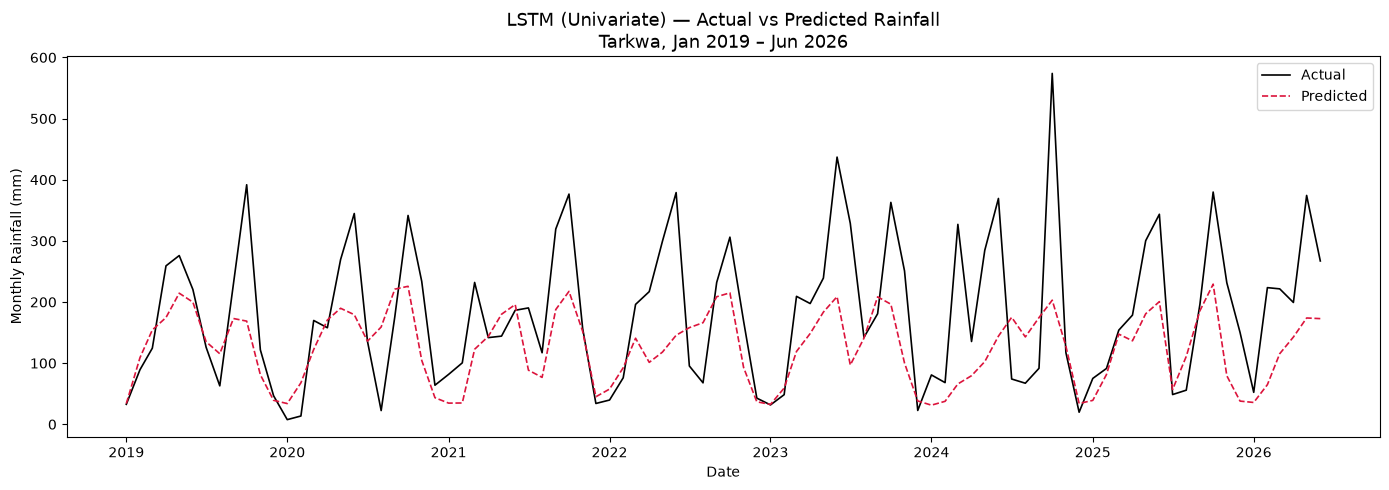

Plot saved.


In [7]:
plt.figure(figsize=(14, 5))
plt.plot(test_dates_aligned.values, y_test,       label='Actual',    color='black', linewidth=1.2)
plt.plot(test_dates_aligned.values, predictions,  label='Predicted', color='crimson',
         linewidth=1.2, linestyle='--')
plt.title('LSTM (Univariate) — Actual vs Predicted Rainfall\nTarkwa, Jan 2019 – Jun 2026',
          fontsize=13)
plt.xlabel('Date')
plt.ylabel('Monthly Rainfall (mm)')
plt.legend()
plt.tight_layout()
os.makedirs('../models', exist_ok=True)
plt.savefig('../models/lstm_uni_actual_vs_predicted.png', dpi=150)
plt.show()
print("Plot saved.")

In [8]:
model.save('../models/lstm_uni_model.keras')
joblib.dump(scaler, '../models/lstm_uni_scaler.pkl')

results = {
    'model': 'LSTM',
    'mode': 'univariate',
    'mae': round(mae, 2),
    'rmse': round(rmse, 2),
    'r2': round(r2, 4),
    'mape': round(mape, 2),
    'lookback': LOOKBACK,
}
with open('../models/lstm_uni_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("Model saved to models/lstm_uni_model.keras")
print("Scaler saved to models/lstm_uni_scaler.pkl")
print("Results saved to models/lstm_uni_results.json")
print(f"\nSummary: LSTM (univariate)")
print(f"  MAE={mae:.2f}  RMSE={rmse:.2f}  R²={r2:.4f}  MAPE={mape:.2f}%")

Model saved to models/lstm_uni_model.keras
Scaler saved to models/lstm_uni_scaler.pkl
Results saved to models/lstm_uni_results.json

Summary: LSTM (univariate)
  MAE=78.91  RMSE=107.86  R²=0.1658  MAPE=54.95%
